In [53]:
import os
import pandas as pd
from glob import glob

# Directory containing the CSV files
csv_dir = 'amd_runs'

# Find all CSV files in the directory
csv_files = glob(os.path.join(csv_dir, '*.csv'))

# Helper function to get base name without suffix
def get_base_name(filename, suffix):
    if filename.endswith(suffix + '.csv'):
        return filename[:-len(suffix + '.csv')]
    elif filename.endswith('.csv'):
        return filename[:-4]
    return filename

amd_raw_metrics = pd.DataFrame()
df_metrics = pd.DataFrame()

# Group files by base name (with and without suffix)
for file_path in csv_files:
    filename = os.path.basename(file_path)
    if filename.endswith('raw_metrics.csv'):
        amd_raw_metrics = pd.concat([amd_raw_metrics, pd.read_csv(file_path)], ignore_index=True)
    else:
        df_metrics = pd.concat([df_metrics, pd.read_csv(file_path)], ignore_index=True)

In [54]:
# Find all CSV files in the directory
csv_files = glob(os.path.join("nvidia_runs", '*.csv'))

nvidia_raw_metrics = pd.DataFrame()

for file_path in csv_files:
    filename = os.path.basename(file_path)
    if filename.endswith('raw_metrics.csv'):
        nvidia_raw_metrics = pd.concat([nvidia_raw_metrics, pd.read_csv(file_path)], ignore_index=True)
    else:
        df_metrics = pd.concat([df_metrics, pd.read_csv(file_path)], ignore_index=True)

df_metrics

,timestamp,gpu_vendor,gpu_name,model,precision,batch_size,epochs,total_time_sec,avg_throughput_samples_per_sec,final_loss,nan_inf_count,skipped_steps,peak_memory_mb,avg_utilization_percent,avg_power_watts
0,2025-09-20T17:30:34.049262,amd,Radeon RX 7900 XT,gpt2,bf16,64,15,374.246149,256.515666,10.840428,0,0,16484.593750,97.273438,266.864583
1,2025-09-20T16:31:46.910636,amd,Radeon RX 7900 XT,bert-large,bf16,64,20,808.181506,158.380264,0.697723,0,0,13569.953125,97.902200,269.991443
2,2025-09-20T17:37:08.571178,amd,Radeon RX 7900 XT,gpt2,bf16,64,15,374.216218,256.536183,10.840428,0,0,16484.613281,97.289817,266.945170
3,2025-09-20T16:45:37.135226,amd,Radeon RX 7900 XT,bert-large,bf16,64,20,808.737652,158.271350,0.697723,0,0,13569.957031,97.875458,269.930403
4,2025-09-20T14:26:37.402512,amd,Radeon RX 7900 XT,resnet50,bf16,256,30,1960.411479,391.754491,2.292358,0,0,13118.425781,99.913310,272.151453
5,2025-09-20T13:53:45.375692,amd,Radeon RX 7900 XT,resnet50,bf16,256,30,2167.532546,354.319939,2.292358,0,0,13119.292969,99.704336,268.656365
6,2025-09-20T12:08:33.723235,amd,Radeon RX 7900 XT,resnet50,fp32,128,30,1461.561438,262.732712,2.307125,0,0,12770.128906,99.348153,269.246238
7,2025-09-20T12:30:55.446922,amd,Radeon RX 7900 XT,resnet50,fp32,128,30,1330.734565,288.562430,2.307203,0,0,12759.023438,99.871525,273.601052
8,2025-09-20T17:23:58.675381,amd,Radeon RX 7900 XT,gpt2,fp16,64,15,378.042796,253.939504,10.837777,0,0,16476.097656,96.801546,266.554124
9,2025-09-20T16:17:57.605412,amd,Radeon RX 7900 XT,bert-large,fp16,64,20,772.388973,165.719611,0.696030,0,0,13564.503906,97.542784,269.841635


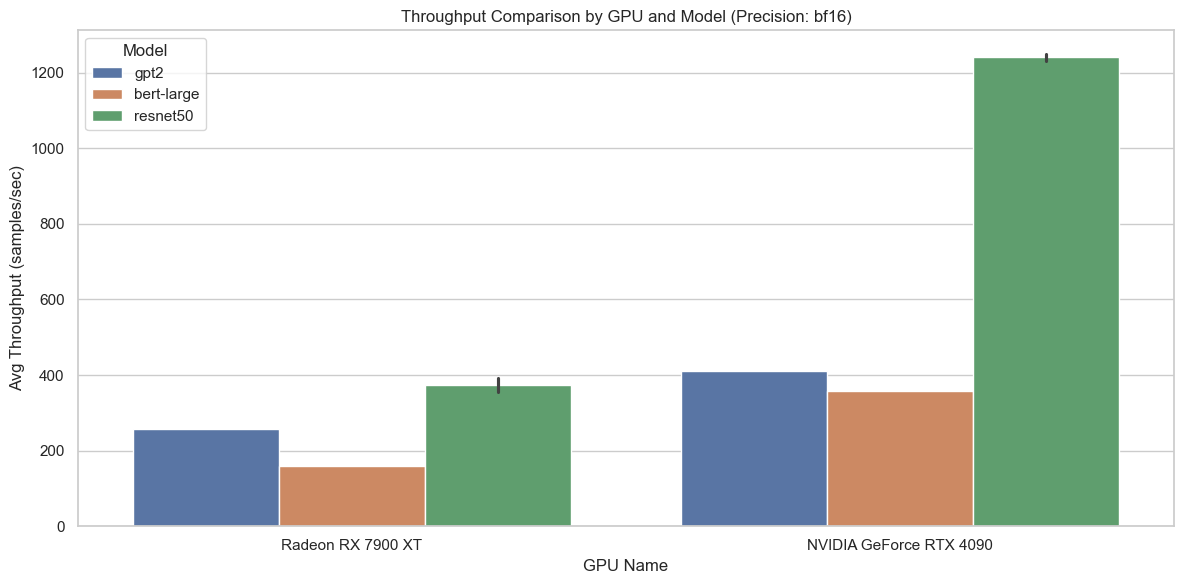

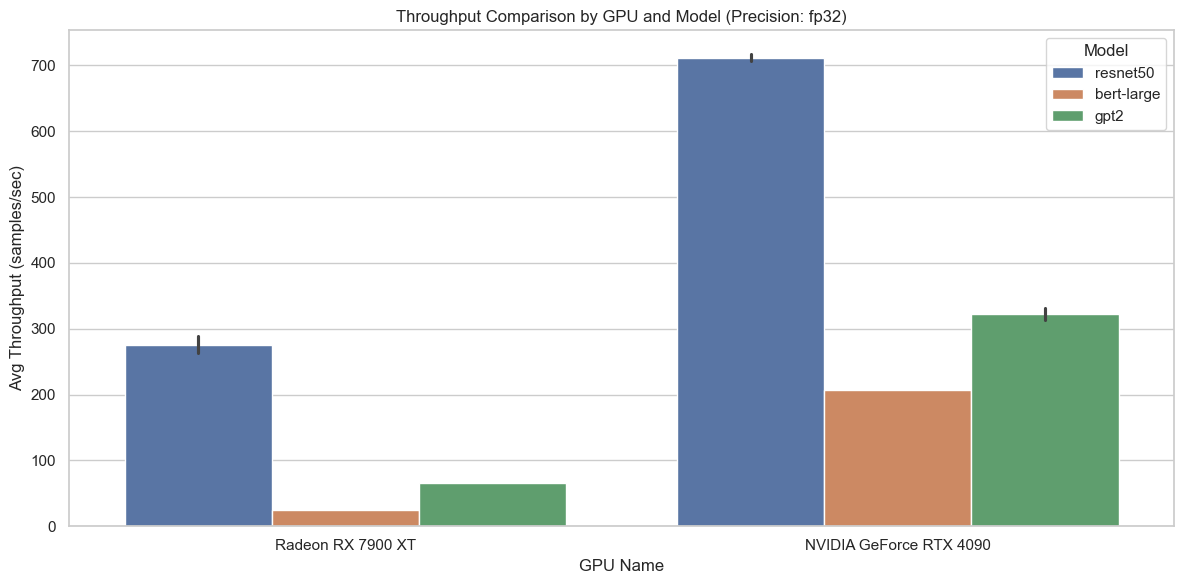

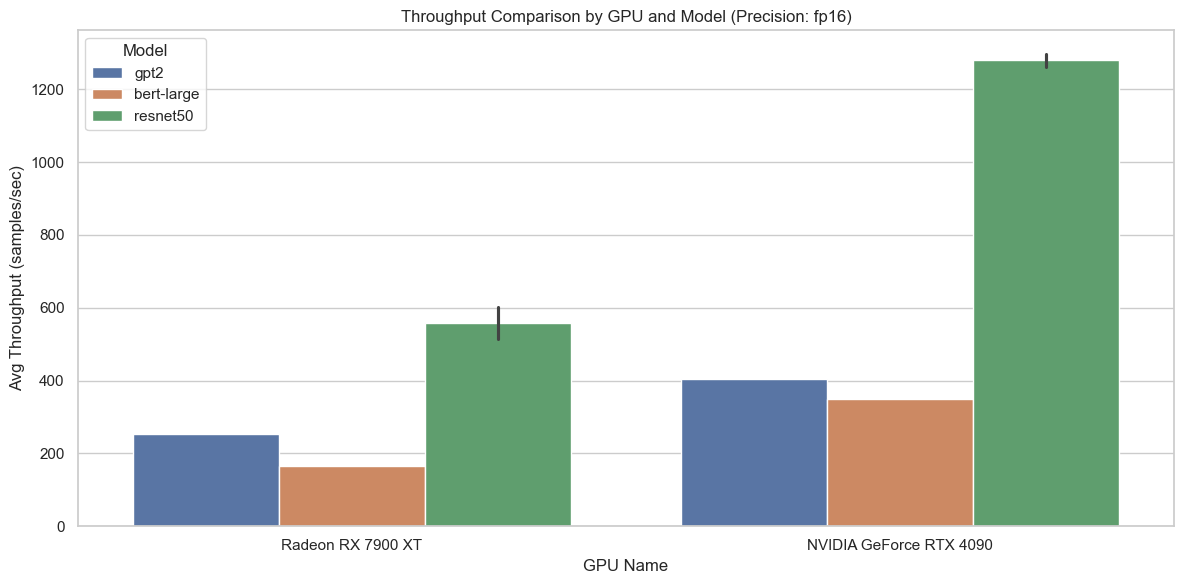

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

for precision in df_metrics['precision'].unique():
    df_prec = df_metrics[df_metrics['precision'] == precision]
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_prec,
        x="gpu_name",
        y="avg_throughput_samples_per_sec",
        hue="model"
    )
    plt.title(f"Throughput Comparison by GPU and Model (Precision: {precision})")
    plt.ylabel("Avg Throughput (samples/sec)")
    plt.xlabel("GPU Name")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()


/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_90745/2640453348.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prec["throughput_per_watt"] = df_prec["avg_throughput_samples_per_sec"] / df_prec["avg_power_watts"]


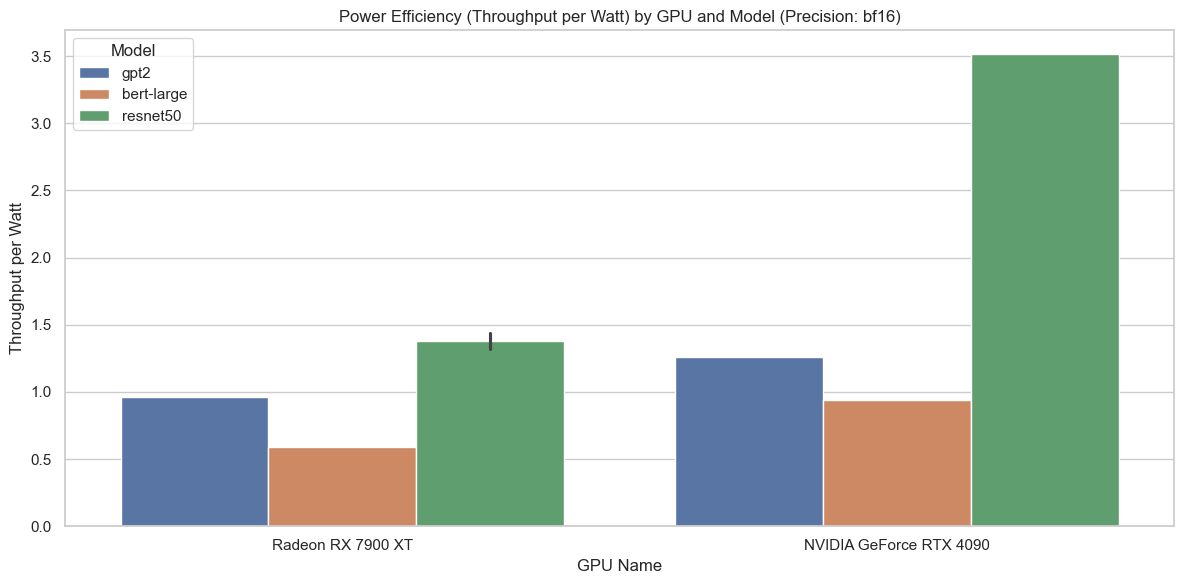

/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_90745/2640453348.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prec["throughput_per_watt"] = df_prec["avg_throughput_samples_per_sec"] / df_prec["avg_power_watts"]


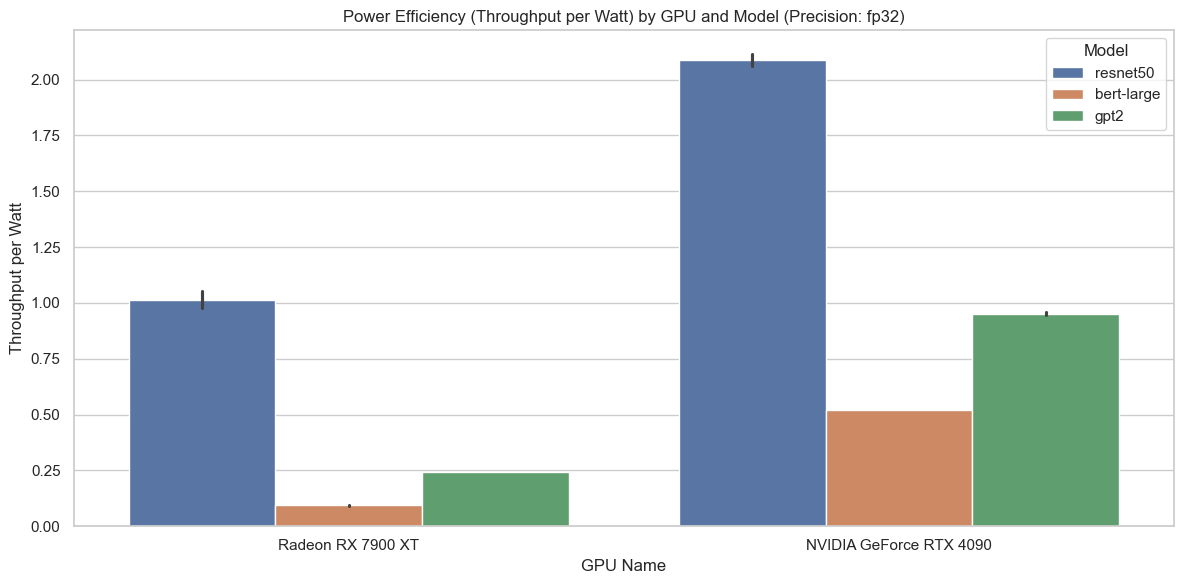

/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_90745/2640453348.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prec["throughput_per_watt"] = df_prec["avg_throughput_samples_per_sec"] / df_prec["avg_power_watts"]


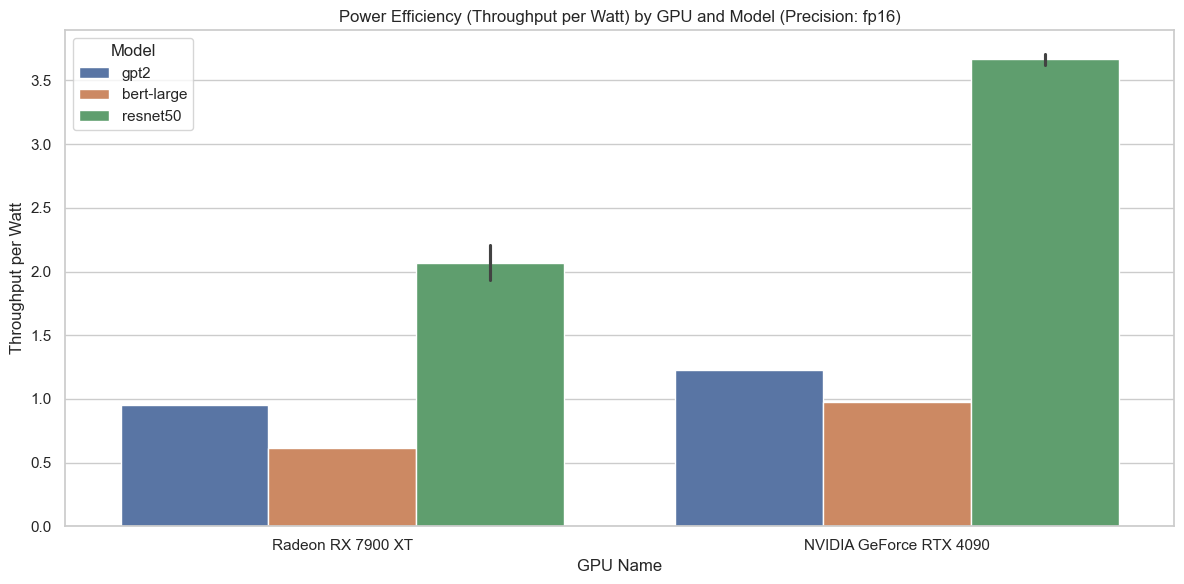

In [56]:
for precision in df_metrics['precision'].unique():
    df_prec = df_metrics[df_metrics['precision'] == precision]
    df_prec["throughput_per_watt"] = df_prec["avg_throughput_samples_per_sec"] / df_prec["avg_power_watts"]
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_prec,
        x="gpu_name",
        y="throughput_per_watt",
        hue="model"
    )
    plt.title(f"Power Efficiency (Throughput per Watt) by GPU and Model (Precision: {precision})")
    plt.ylabel("Throughput per Watt")
    plt.xlabel("GPU Name")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

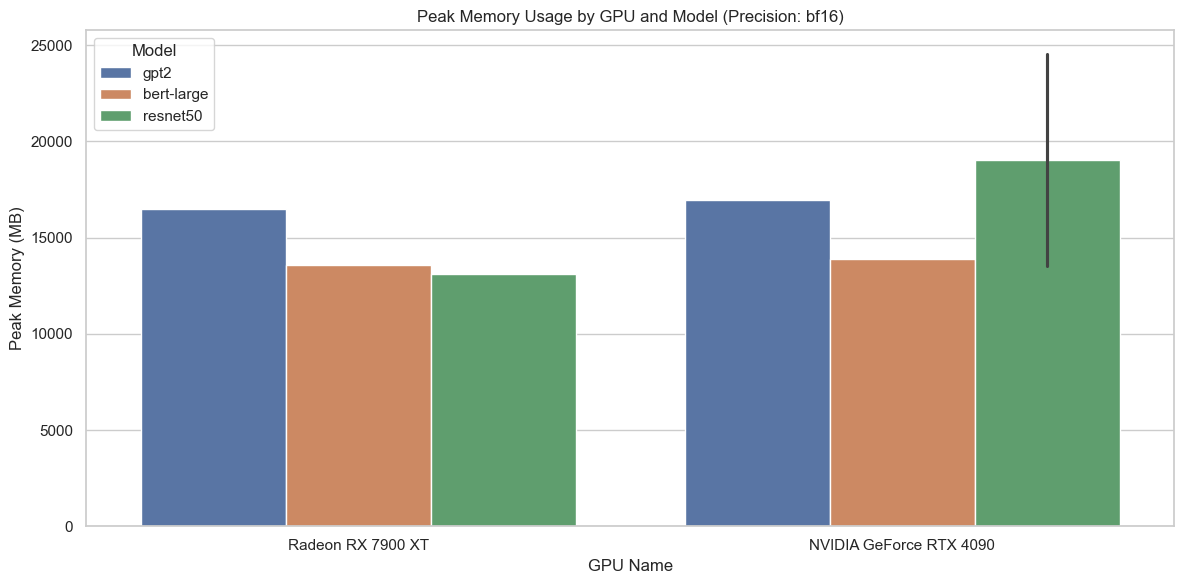

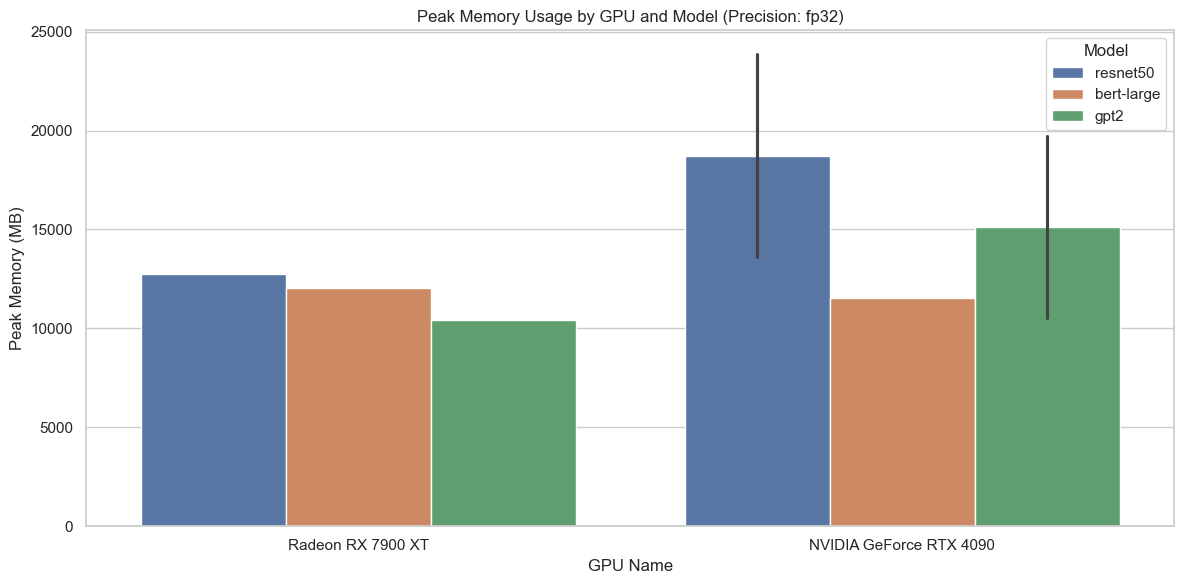

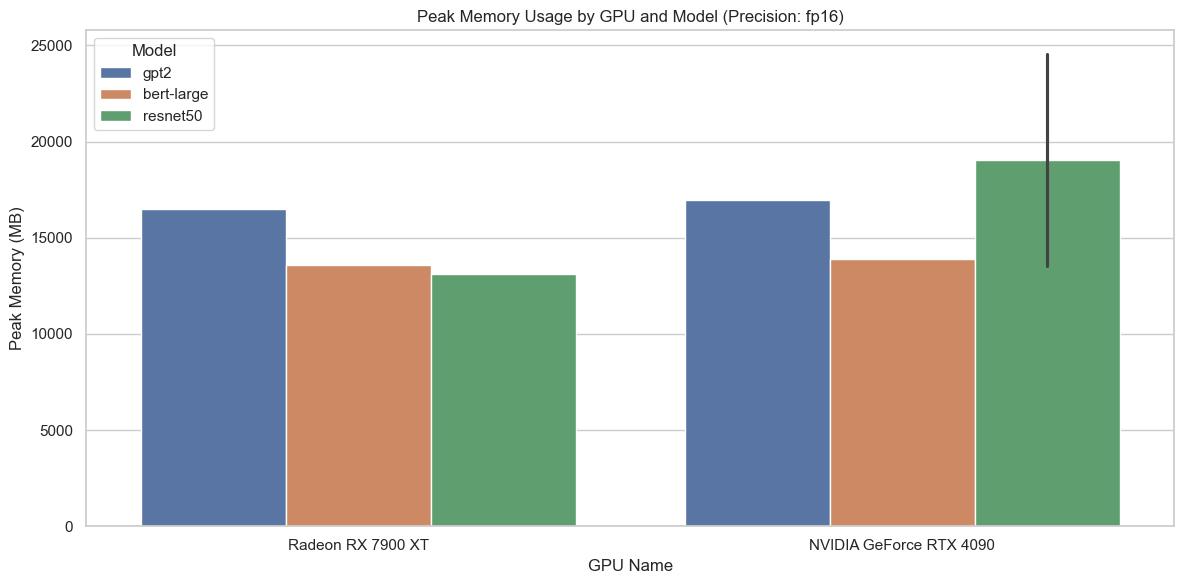

In [57]:
for precision in df_metrics['precision'].unique():
    df_prec = df_metrics[df_metrics['precision'] == precision]
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_prec,
        x="gpu_name",
        y="peak_memory_mb",
        hue="model"
    )
    plt.title(f"Peak Memory Usage by GPU and Model (Precision: {precision})")
    plt.ylabel("Peak Memory (MB)")
    plt.xlabel("GPU Name")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

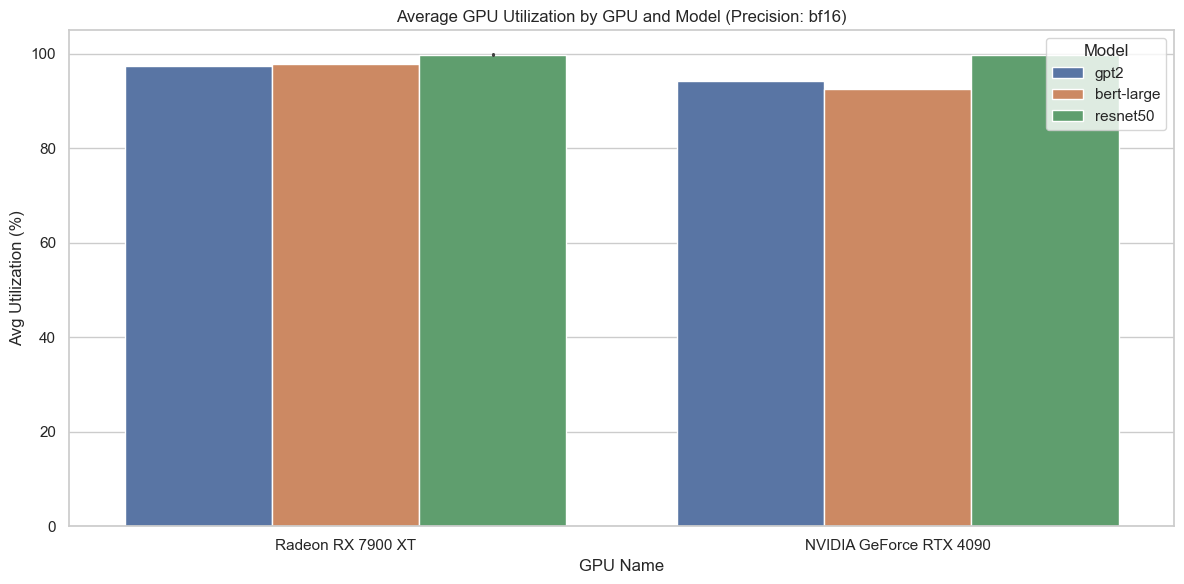

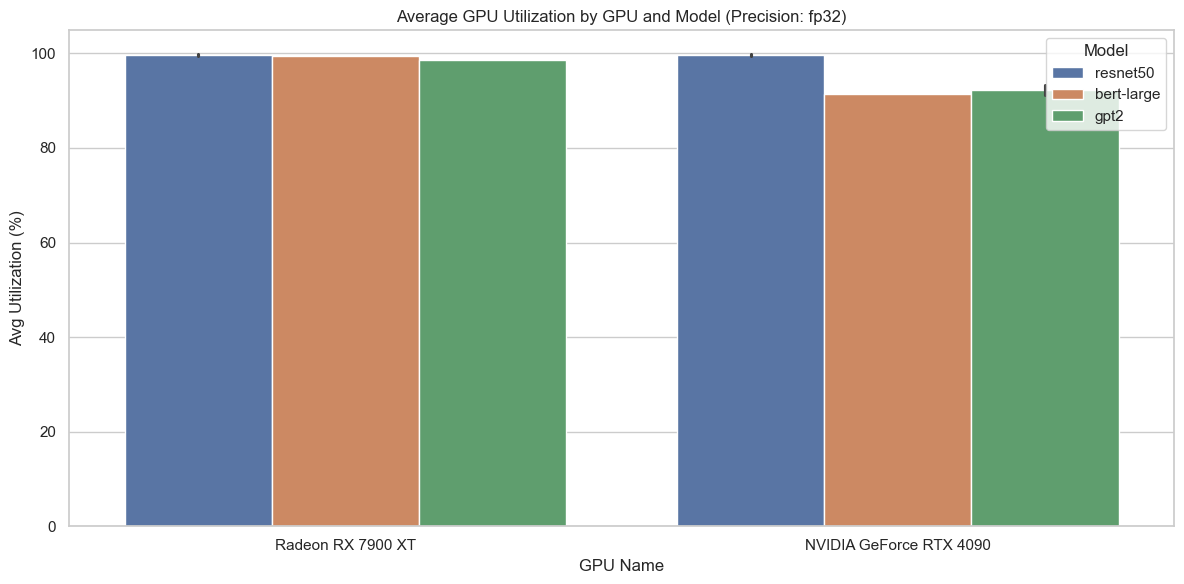

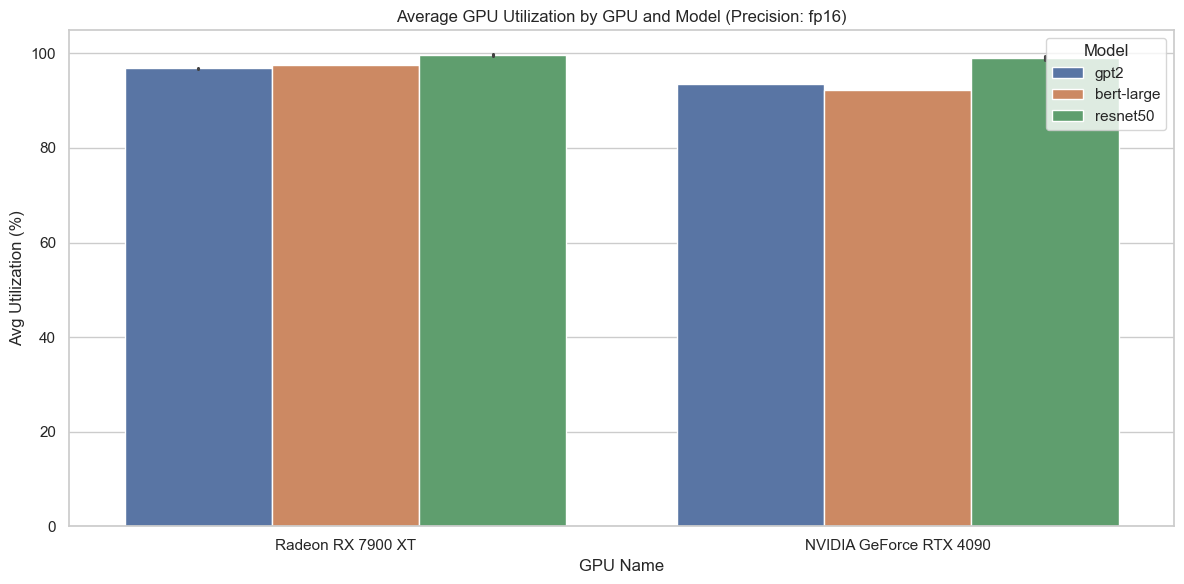

In [58]:
for precision in df_metrics['precision'].unique():
    df_prec = df_metrics[df_metrics['precision'] == precision]
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_prec,
        x="gpu_name",
        y="avg_utilization_percent",
        hue="model"
    )
    plt.title(f"Average GPU Utilization by GPU and Model (Precision: {precision})")
    plt.ylabel("Avg Utilization (%)")
    plt.xlabel("GPU Name")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()